In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import gridspec, rcParams
from datetime import datetime as dt, timedelta
import pingouin as pg
import scipy.stats as stats
from fish import Gafftopsail
sys.path.append(r'/Users/zichenhe/miniforge3/envs/naumann_lab/2ptank/')#(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = ('C:/Data/Imaging/251224_overlap/fish2//')
rcParams['font.size'] = 4

In [3]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging'], sequence = 5)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]
f_pertrial_dict = barcode.get_pertrial_f(fish)

smoothed
smoothed
smoothed
smoothed
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s


__barcoding 1: large response__

selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


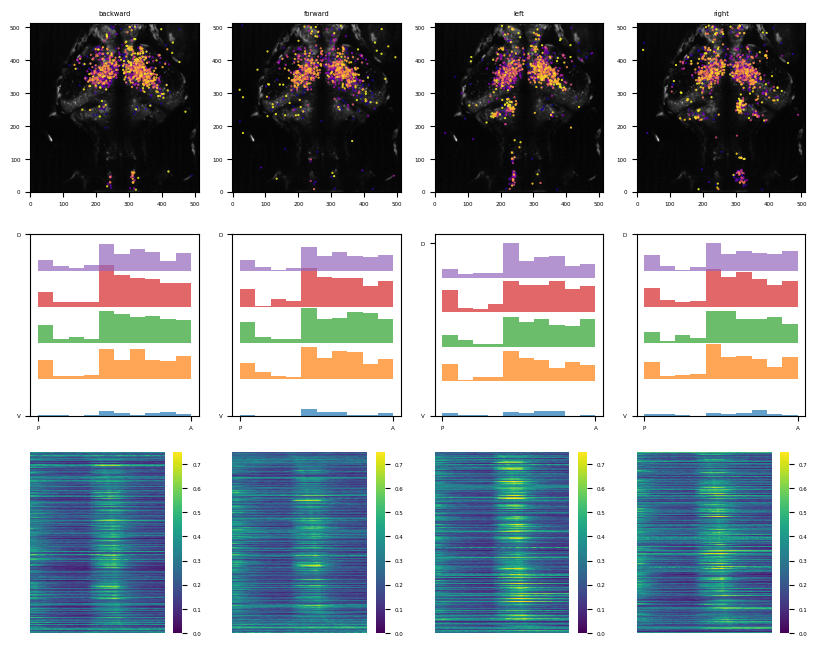

In [4]:
barred_gratingneurons = barcode.select_gratingbarcode(fish, f_pertrial_dict, baseline_s = 5, response_s =7, perc_trial_threshold = 0.8)
barred_gratingneurons = barcode.sort_gratingneurons(fish, f_pertrial_dict, barred_gratingneurons)
fig = barcode.plot_gratingneurons(fish, f_pertrial_dict, barred_gratingneurons)
plt.savefig(fish.path + 'Graphs//grating_barcode.png')
plt.show()
plt.close()

DOT CELLS

selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


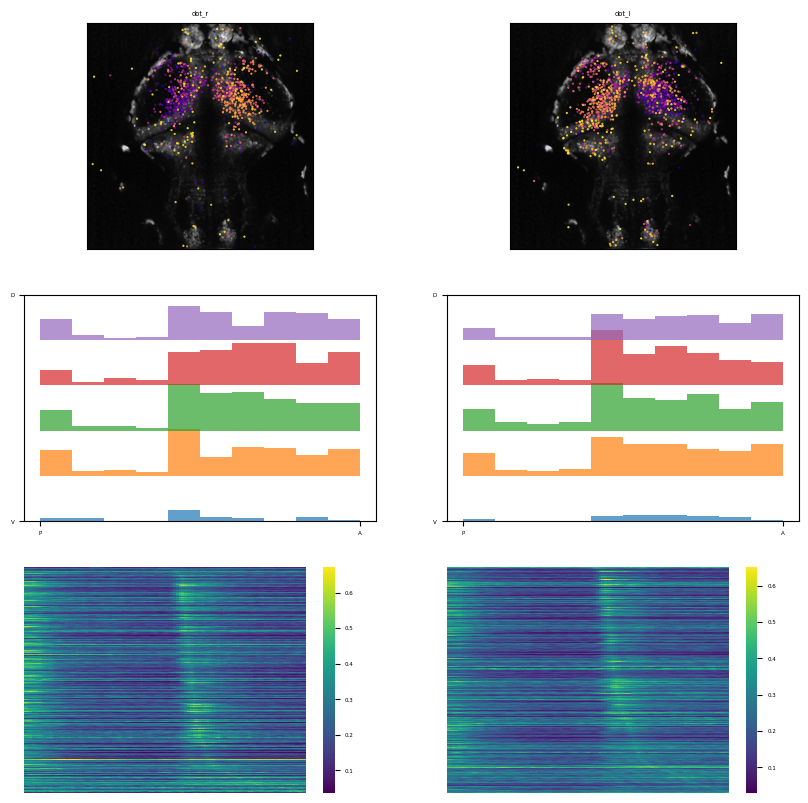

In [5]:
barred_dotneurons = barcode.select_dotbarcode(fish, f_pertrial_dict, baseline_s=5, response_s=7,
                                              perc_trial_threshold=0.8)
barred_dotneurons = barcode.sort_dotneurons(fish, f_pertrial_dict, barred_dotneurons)
fig = barcode.plot_dotneurons(fish, f_pertrial_dict, barred_dotneurons)
#plt.savefig(fish.path + 'Graphs//dot_barcode.png')
plt.show()
plt.close()

OVERLAP CELLS

baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
baseline starts at t0 = 20
selection criteria: max >= baseline max * 1.8
sorted from t0 = 24
sorted from t0 = 24
sorted from t0 = 24
sorted from t0 = 24
sorted from t0 = 24
sorted from t0 = 24
sorted from t0 = 24
sorted from t0 = 24


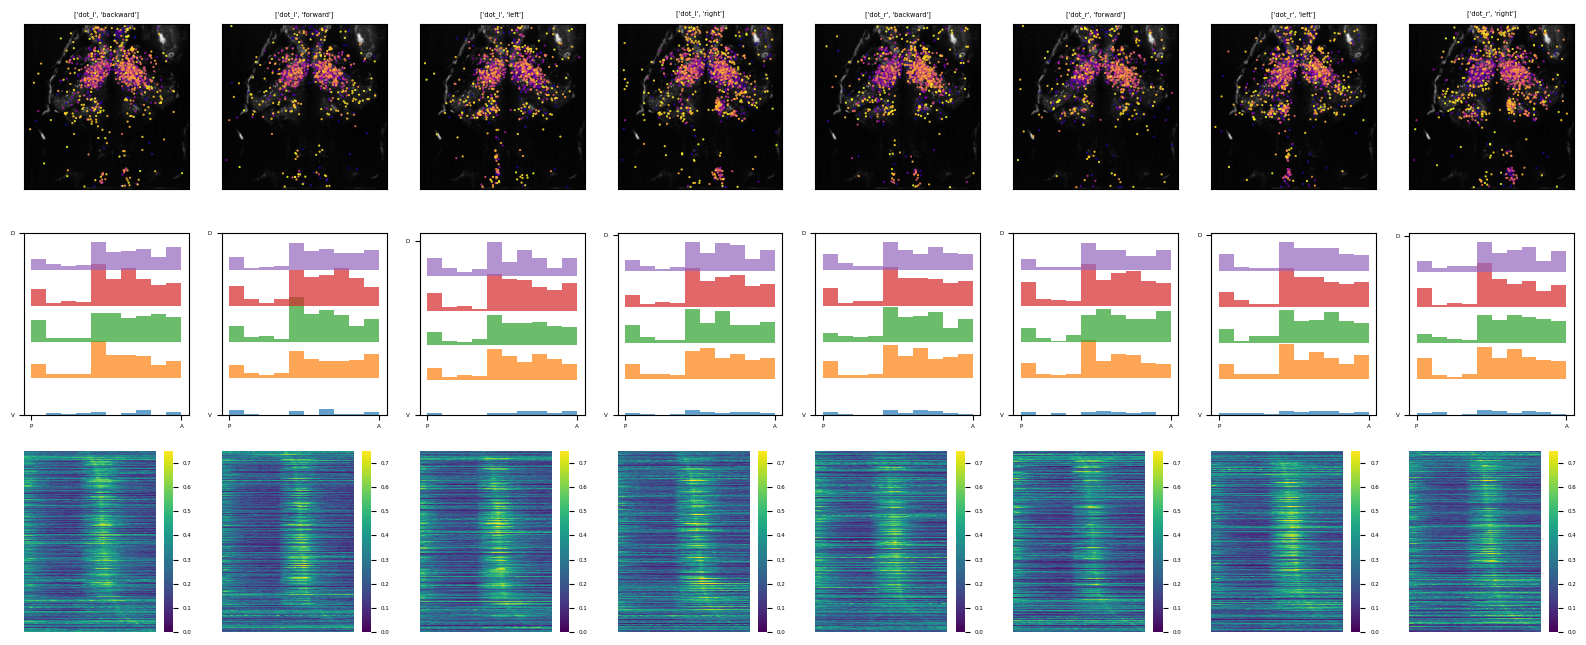

In [6]:
barred_overlapneurons = barcode.select_overlapbarcode(fish, f_pertrial_dict, baseline_s=5, response_s=5, perc_trial_threshold=0.8)
barred_overlapneurons = barcode.sort_overlapneurons(fish, f_pertrial_dict, barred_overlapneurons)
fig = barcode.plot_overlapneurons(fish, f_pertrial_dict, barred_overlapneurons)
#plt.savefig(fish.path + 'Graphs//overlap_barcode.png')
plt.show()
plt.close()

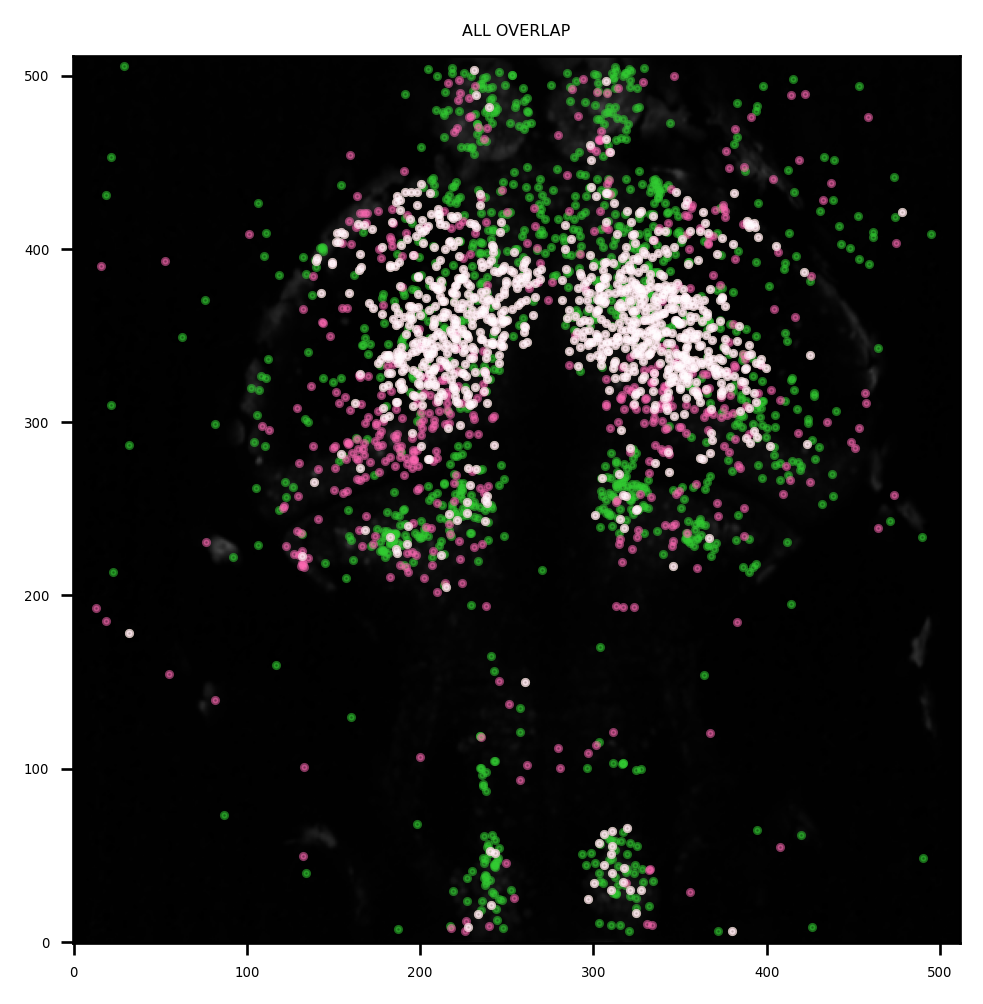

In [7]:
#plot all neurons overlap
def plot_sharedcells(fish, barred_gratingneurons, barred_dotneurons):
    fig, ax = plt.subplots(1, 1, dpi = 240)
    omr_sets = [set(barred_gratingneurons[s]) for s in barred_gratingneurons.keys()]
    omr_sets = set.union(*omr_sets)
    dot_sets = [set(barred_dotneurons[s]) for s in barred_dotneurons.keys()]
    dot_sets = set.union(*dot_sets)
    overlap_sets =  list(omr_sets & dot_sets)
    ax.imshow(fish.img_dict[0], cmap='Greys_r', origin='lower', vmax=800)
    ax.scatter(fish.pos_all.loc[list(omr_sets), 'xpos'], fish.pos_all.loc[list(omr_sets), 'ypos'],
            s=3, facecolor='limegreen', alpha=0.5)
    ax.scatter(fish.pos_all.loc[list(dot_sets), 'xpos'], fish.pos_all.loc[list(dot_sets), 'ypos'],
            s=3, facecolor='hotpink', alpha=0.5)
    ax.scatter(fish.pos_all.loc[overlap_sets, 'xpos'], fish.pos_all.loc[overlap_sets, 'ypos'],
            s=3, facecolor='white', alpha=0.5)
    ax.set_title('ALL OVERLAP')
    return fig
fig = plot_sharedcells(fish, barred_gratingneurons, barred_dotneurons)
#plt.savefig(fish.path + 'Graphs//shared_all.png')
plt.show()
plt.close()

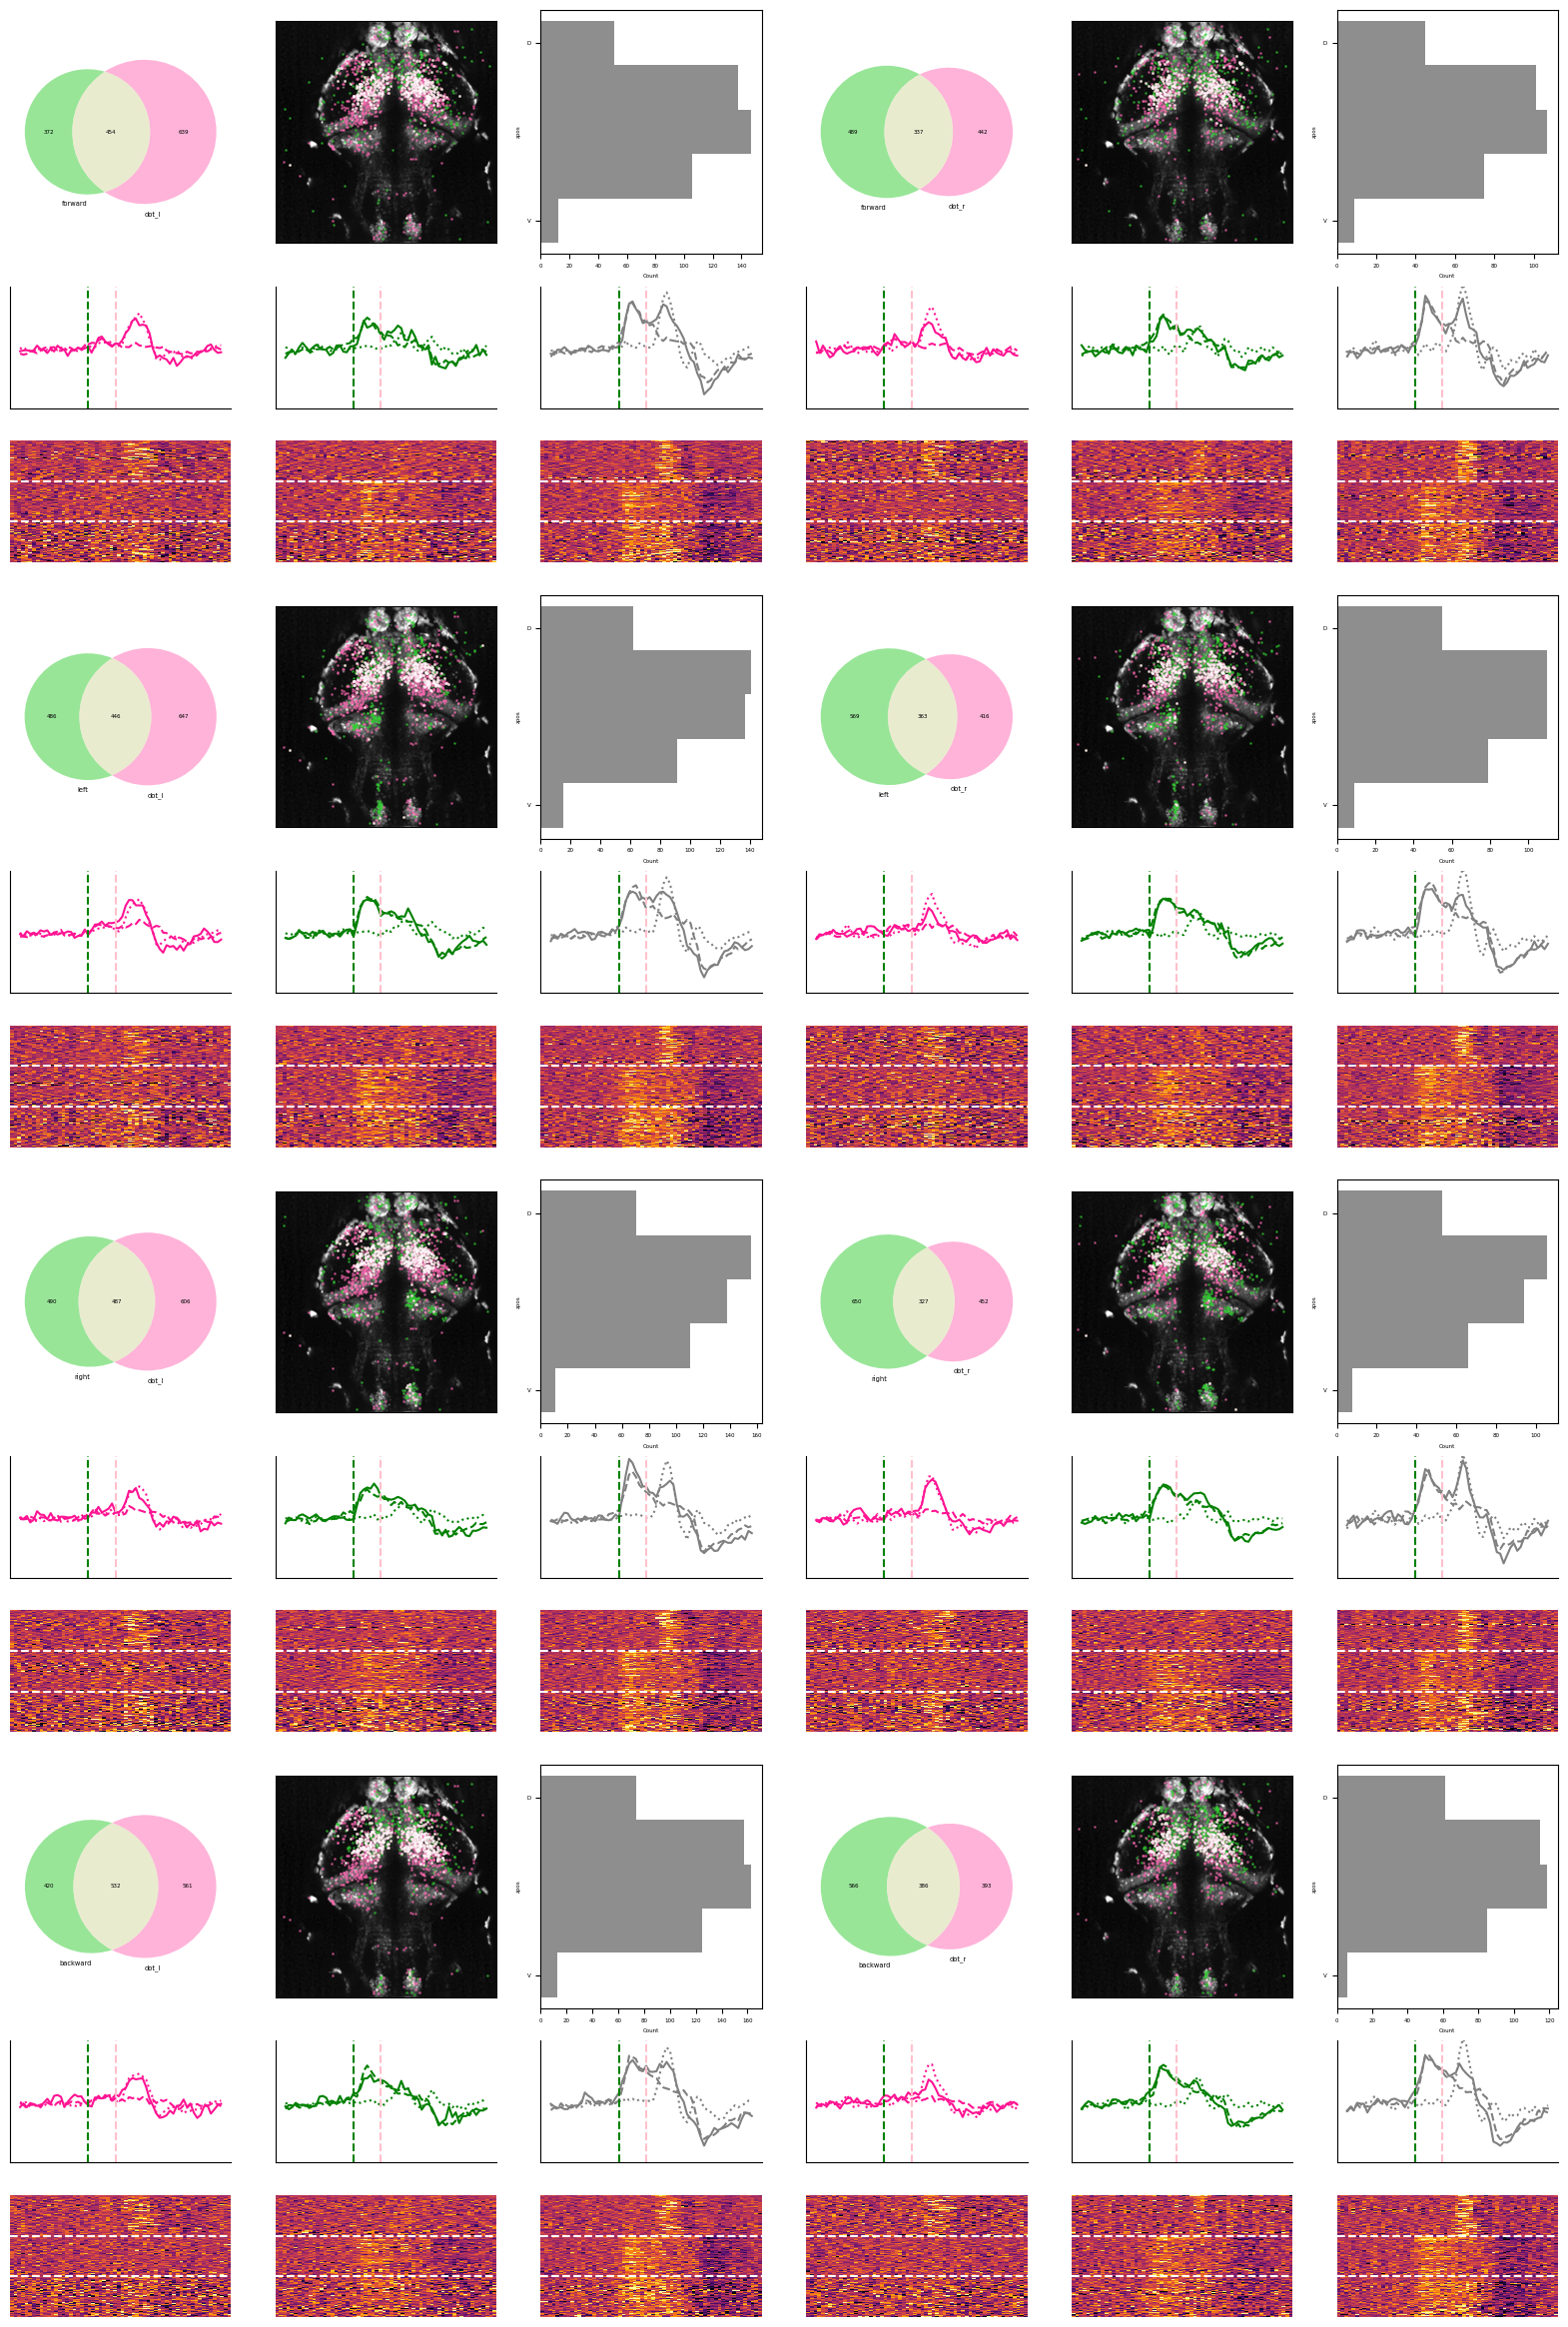

In [14]:
import itertools
from matplotlib_venn import venn2, venn3
def plot_shared_cells(fish, barred_gratingneurons, barred_dotneurons, barred_overlapneurons, baseline_s = 10, response_s = 20, stationary_s = 20):
    dot_stim = ['dot_l', 'dot_r']
    omr_stim = ['forward', 'left', 'right', 'backward']
    baseline_frame = int(baseline_s//fish.image_s)
    response_frame = int(response_s//fish.image_s)
    stationary_frame = int(stationary_s//fish.image_s)

    n_inpos = set(list(fish.pos_all[(fish.pos_all.ypos>0) & (fish.pos_all.ypos<500)].index))

    fig, ax = plt.subplots(len(omr_stim) * 3, len(dot_stim) * 3, figsize = (20, 30), gridspec_kw={'height_ratios': [2, 1, 1] * len(omr_stim)})
    for i, (omr, dot) in enumerate(itertools.product(omr_stim, dot_stim)):#for each of the overlapping stimulus
        omr_set = set(barred_gratingneurons[omr])
        omr_set = (omr_set & n_inpos)
        dot_set = set(barred_dotneurons[dot])
        dot_set = (dot_set & n_inpos)
        dot_only = list(dot_set - omr_set)      # in dot, not in grating
        grating_only = list(omr_set - dot_set)      # in grating, not in dot
        overlap_true = set(barred_overlapneurons[str([dot, omr])])
        overlap_only = list(overlap_true - omr_set - dot_set)
        overlap = list(omr_set & dot_set)
        axrow = i//2 * 3
        axbigcol = i%2

        # --- (1) Venn diagram ---
        ax_venn = ax[axrow, axbigcol * 3]
        venn2([omr_set, dot_set], set_labels=(omr, dot), ax=ax_venn, set_colors=('limegreen', 'hotpink'),alpha=0.5)
        # venn3([omr_set, dot_set, overlap_true], set_labels=(omr, dot, str([dot, omr])), ax=ax_venn, set_colors=('limegreen', 'hotpink', 'grey'),alpha=0.5)

        # --- (2) Spatial map ---
        ax_img = ax[axrow, axbigcol * 3 + 1]
        ax_img.imshow(fish.img_dict[0], cmap='Greys_r', origin='lower', vmax=120)
        ax_img.scatter(fish.pos_all.loc[list(omr_set), 'xpos'], fish.pos_all.loc[list(omr_set), 'ypos'],
            s=1, facecolor='limegreen', label=omr, alpha=0.5)
        ax_img.scatter(fish.pos_all.loc[list(dot_set), 'xpos'], fish.pos_all.loc[list(dot_set), 'ypos'],
            s=1, facecolor='hotpink', label=dot, alpha=0.5)
        # highlight overlap neurons
        ax_img.scatter(fish.pos_all.loc[list(overlap), 'xpos'], fish.pos_all.loc[list(overlap), 'ypos'],
            s=1,  facecolor='white', label='overlap', alpha=.5)
        ax_img.grid(False)
        ax_img.set_xticks([])
        ax_img.set_yticks([])

        # --- (3) zpos ---
        ax_zpos = ax[axrow, axbigcol * 3 + 2]
        #look at zpos and ypos
        # for offset, plane in enumerate(fish.planes[::-1]):
        #     n_plane = np.where(fish.pos_all.loc[overlap, 'zpos'] == plane)
        #     counts, bins = np.histogram(fish.pos_all.loc[n_plane]['ypos'], bins=20, range = [0, fish.img_dict[0].shape[0]])
        #     perc = [i/len(overlap) for i in counts]
        #     ax_zpos.bar(bins[:-1], perc, width=np.diff(bins), align='edge', alpha=0.7, bottom=offset * .07)
        #
        #     ax_zpos.grid(False)
        #     ax_zpos.set_xticks([0, fish.img_dict[0].shape[0]])
        #     ax_zpos.set_xticklabels(['P', 'A'])
        #     ax_zpos.set_yticks([0, len(fish.planes) * .07])
        #     ax_zpos.set_yticklabels(['V', 'D'])
        #only look at zpos
        sns.histplot(fish.pos_all.loc[overlap], y = 'zpos', bins = len(fish.planes), discrete=True, ax=ax_zpos, linewidth = 0, color = 'dimgrey')
        ax_zpos.invert_yaxis()
        ax_zpos.set_yticks([0, len(fish.planes) - 1])
        ax_zpos.set_yticklabels(['D', 'V'])

        # ___ (4) response___

        overlap_stim = str([dot, omr])
        clist = ['deeppink', 'green', 'grey']#colored according to neuron groups
        linelist = [':', '--', '-']
        for i, n in enumerate([dot_only, grating_only, list(overlap)]):
            ax_response = ax[axrow + 1, axbigcol * 3 + i]
            ax_heatmapresponse = ax[axrow + 2, axbigcol * 3 + i]
            f_collection = []
            for si, s in enumerate([dot, omr, overlap_stim]):
                trace_perneuron = np.diff(f_pertrial_dict[s][:, n, stationary_frame - baseline_frame:stationary_frame + response_frame]).mean(axis = 0)
                f_collection.append(trace_perneuron)
                ax_response.plot(trace_perneuron.mean(axis = 0), c = clist[i], linestyle = linelist[si])
            sns.heatmap(np.concatenate(f_collection), ax = ax_heatmapresponse, xticklabels= [], yticklabels = [], vmin = -0.06, vmax = 0.06, cmap = 'inferno', cbar = False)
            ax_response.axvline(20//fish.image_s - stationary_frame + baseline_frame, linestyle = '--', color = 'green')
            ax_response.axvline(24//fish.image_s - stationary_frame + baseline_frame, linestyle = '--', color = 'pink')
            ax_response.set_ylim([-0.03, 0.03])
            ax_response.set_xticks([])
            ax_response.set_yticks([])
            ax_response.set_xticklabels([])
            ax_response.set_yticklabels([])
            ax_response.spines[['top', 'right']].set_visible(False)

            ax_heatmapresponse.axhline(f_collection[0].shape[0], linestyle = '--', color = 'white')
            ax_heatmapresponse.axhline(f_collection[0].shape[0] * 2, linestyle = '--', color = 'white')
    return fig
fig = plot_shared_cells(fish, barred_gratingneurons, barred_dotneurons, barred_overlapneurons)
plt.savefig(fish.path + '//Graphs//shared_stim.png')
plt.show()
plt.close()

In [16]:
set(barred_gratingneurons['forward']) & set(barred_dotneurons['dot_l'])

{19,
 22,
 31,
 65,
 67,
 82,
 105,
 114,
 125,
 129,
 138,
 157,
 186,
 191,
 216,
 237,
 275,
 278,
 282,
 331,
 339,
 365,
 376,
 401,
 403,
 429,
 441,
 474,
 506,
 513,
 516,
 537,
 597,
 638,
 644,
 661,
 678,
 746,
 757,
 779,
 845,
 847,
 861,
 874,
 884,
 933,
 938,
 957,
 982,
 1007,
 1012,
 1025,
 1031,
 1034,
 1038,
 1052,
 1057,
 1059,
 1060,
 1061,
 1064,
 1065,
 1072,
 1089,
 1091,
 1092,
 1103,
 1104,
 1105,
 1109,
 1128,
 1136,
 1138,
 1139,
 1145,
 1156,
 1167,
 1172,
 1179,
 1183,
 1191,
 1193,
 1194,
 1197,
 1198,
 1209,
 1213,
 1218,
 1222,
 1235,
 1239,
 1250,
 1259,
 1266,
 1267,
 1268,
 1278,
 1279,
 1306,
 1311,
 1315,
 1323,
 1324,
 1351,
 1372,
 1377,
 1382,
 1383,
 1386,
 1389,
 1397,
 1413,
 1423,
 1426,
 1427,
 1438,
 1441,
 1446,
 1449,
 1474,
 1479,
 1482,
 1486,
 1499,
 1502,
 1507,
 1510,
 1515,
 1524,
 1534,
 1543,
 1552,
 1576,
 1592,
 1594,
 1600,
 1601,
 1620,
 1628,
 1654,
 1655,
 1669,
 1694,
 1695,
 1696,
 1700,
 1712,
 1716,
 1723,
 1729,
 1748

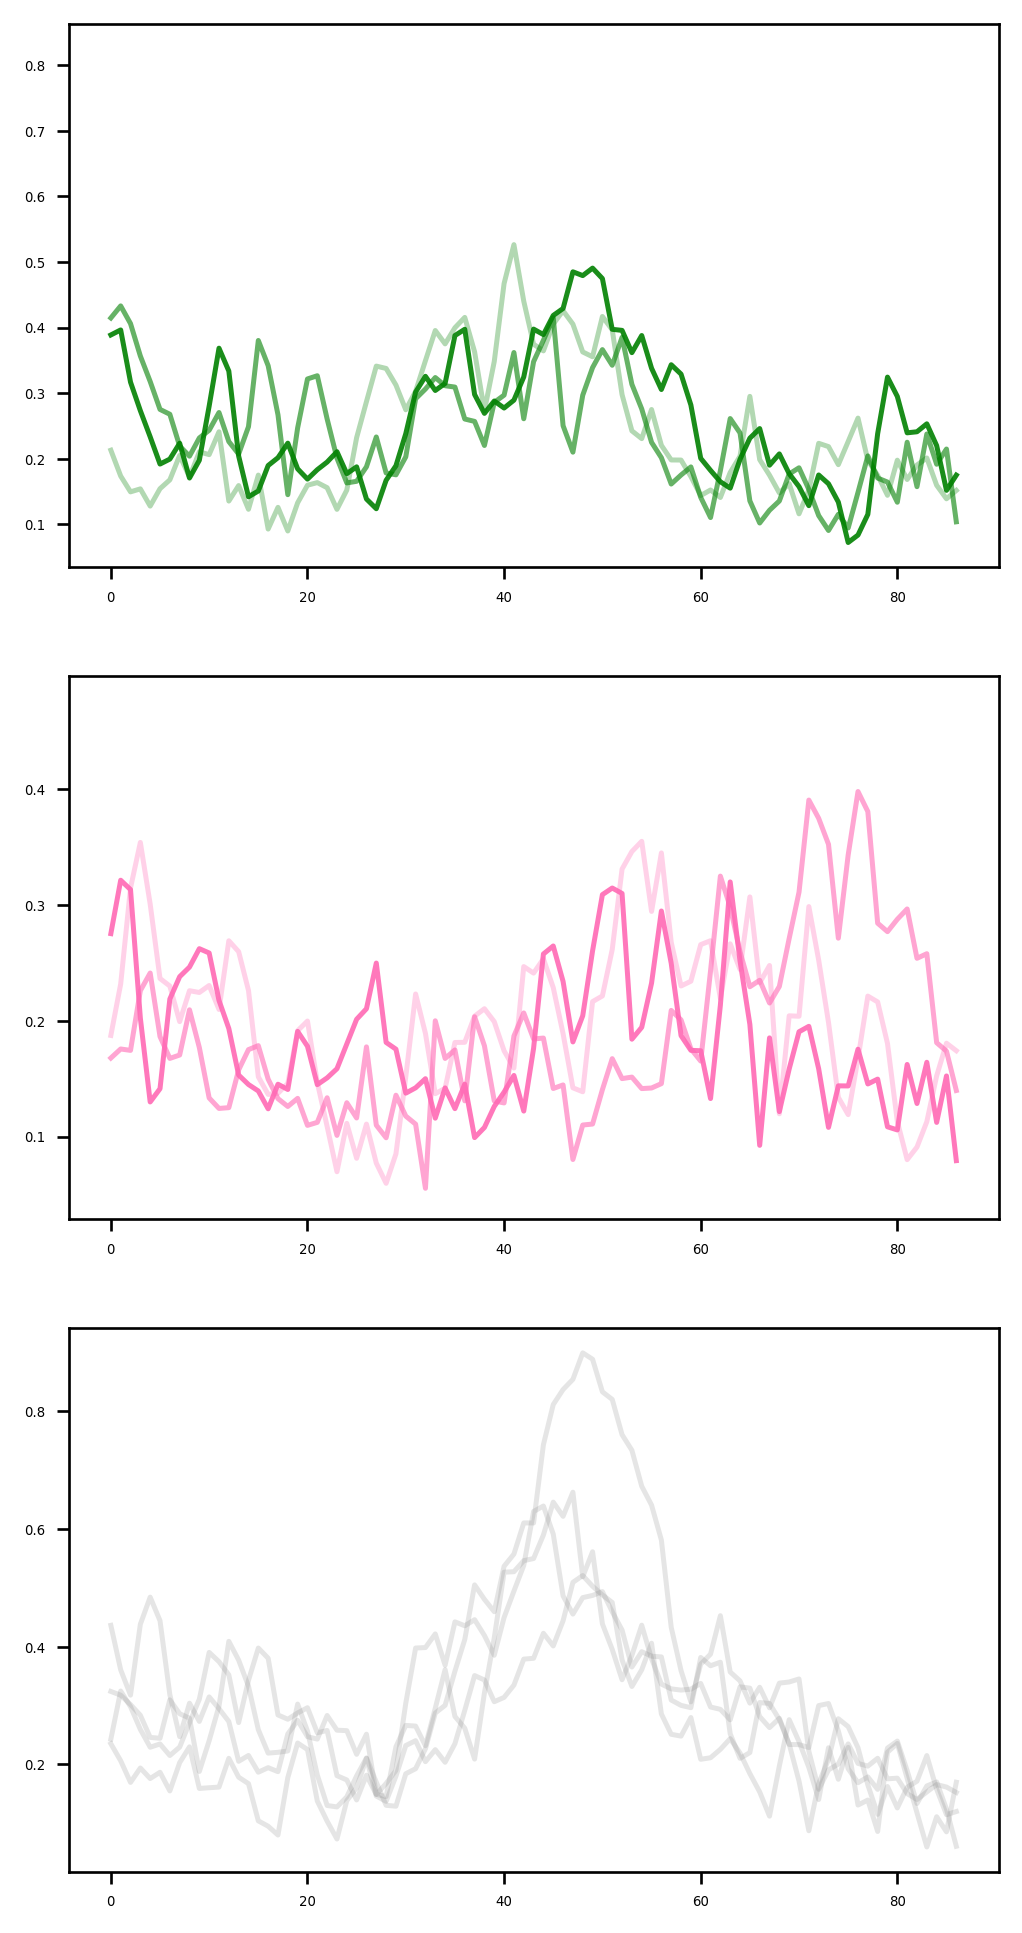

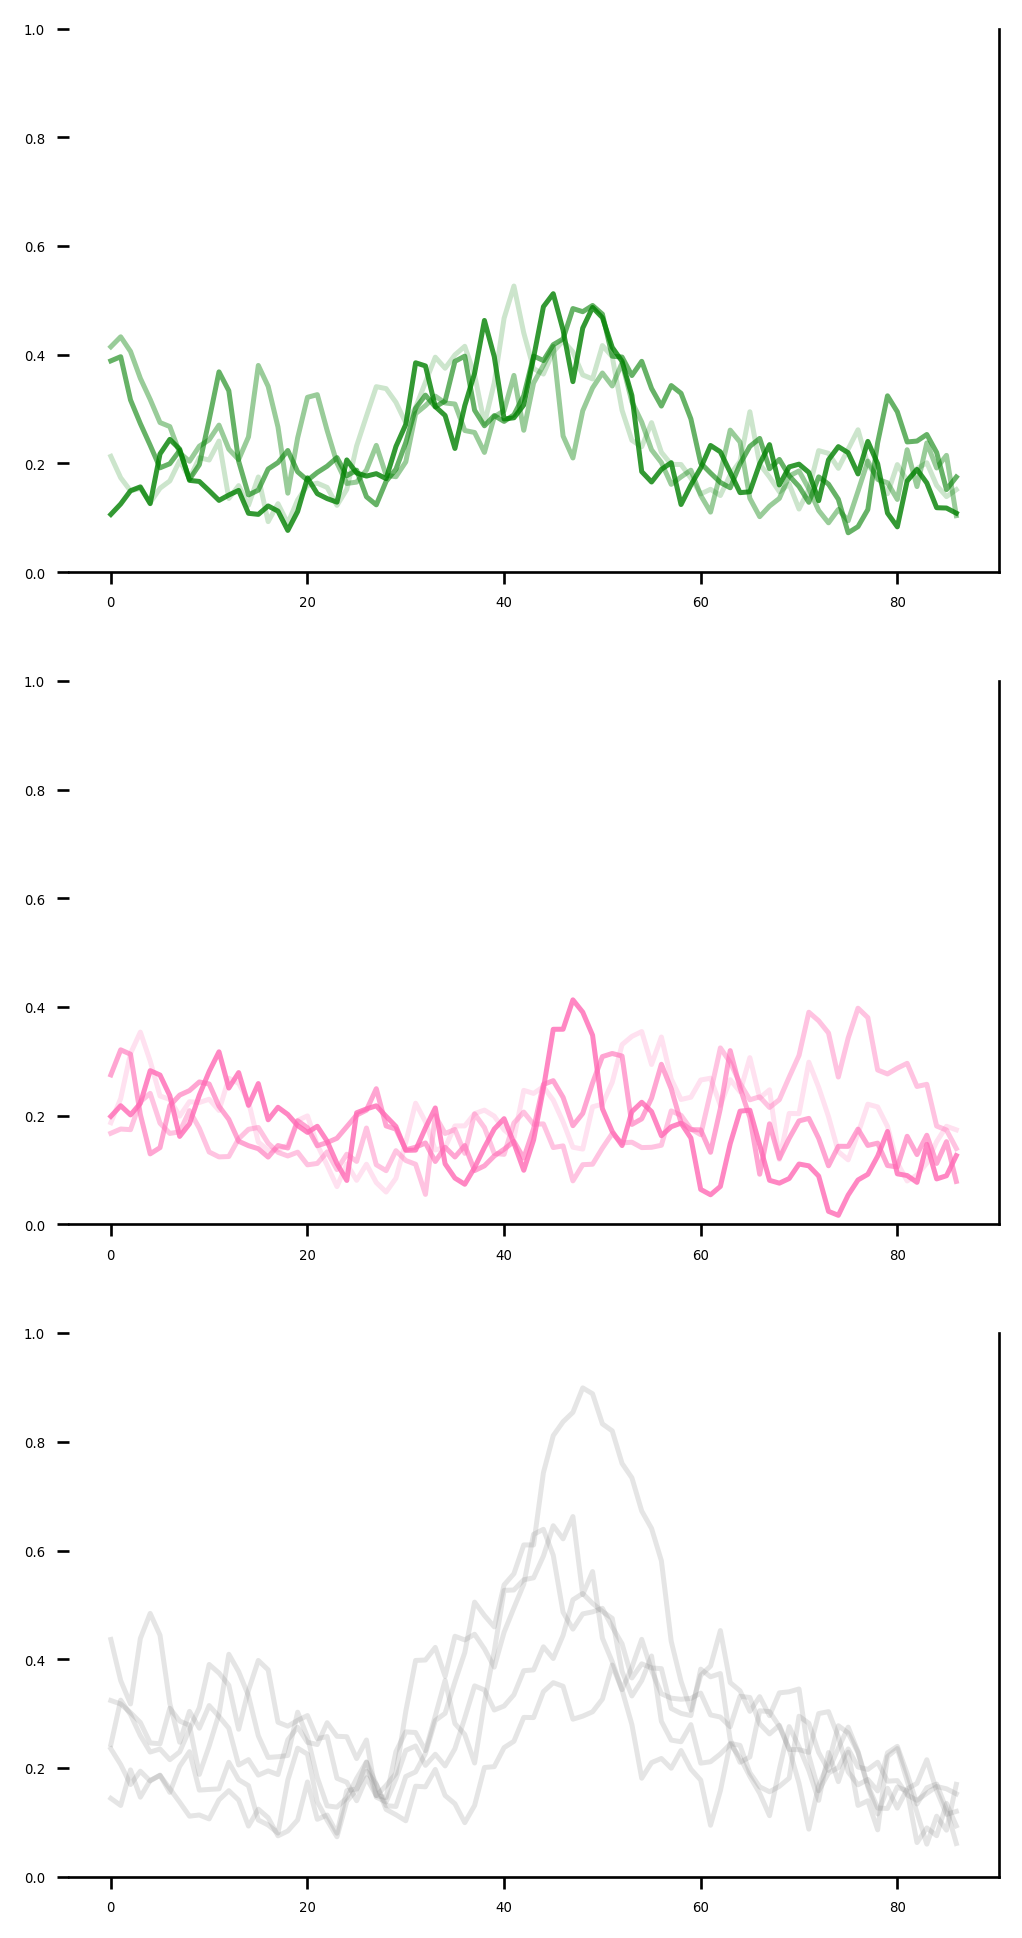

In [63]:
fig, ax = plt.subplots(3, 1, dpi = 240, figsize = (5, 10))
n = 365
for trial in range(5):
    ax[0].plot(f_pertrial_dict['forward'][trial, n, 15:], c = 'green', alpha = 0.2 * trial)
    ax[1].plot(f_pertrial_dict['dot_l'][trial, n, 15:], c = 'hotpink', alpha = 0.2 * trial)
    ax[2].plot(f_pertrial_dict[str(['dot_l', 'forward'])][trial, n, 15:], c = 'grey', alpha = 0.2)
# ax[0].plot(f_pertrial_dict['forward'][:, n, 15:].mean(axis = 0), c = 'green')
# ax[1].plot(f_pertrial_dict['dot_l'][:, n, 15:].mean(axis = 0), c = 'hotpink')
# ax[2].plot(f_pertrial_dict[str(['dot_l', 'forward'])][:, n, 15:].mean(axis = 0), c = 'grey')
for axis in ax:
    axis.set_ylim([0, 1])
    axis.spines[['top', 'left']].set_visible(False)
#fig.savefig(r"C:\Users\Zichen\Desktop\deletelater//multiplex_example.svg")
plt.show()
plt.close()

In [59]:
plt.imshow(fish.img_dict[3], origin = 'lower')
plt.scatter(fish.pos_all.loc[n, 'xpos'], fish.pos_all.loc[n, 'ypos'])

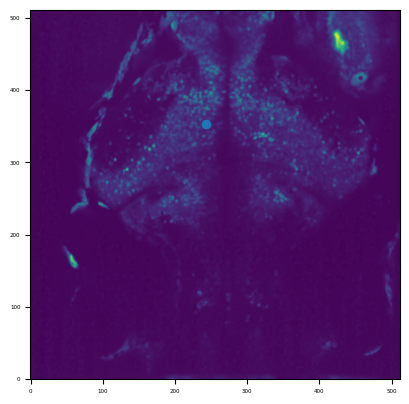

In [60]:
plt.show()
plt.close()